In [677]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import os

C1 = '#f5f4b3' #'#3DB2FF' #'#FFAF45'
C2 = '#898|21' #'salmon'  #'#FB6D48'
C3 = '#1f4529'#'green'   #'#D74B76'
C4 = '#abba7c'#'#673F69' #'#673F69'
C5 = '#FFAF45'
C6 = '#bccbf1'

In [749]:
def read_csv_file(filename: str) -> dict:
    d = {}
    with open(filename, 'r') as rd:
        lines= rd.readlines()
        
    header = lines[0]
    header = header.strip().split(',')[1:]
    for line in lines[1:]:
        x = line.strip().split(',')
        if len(x) == 1:
            continue
        workload = x[0]
        for i in range(len(header)):
            if workload not in d:
                d[workload] = {}
            d[workload][header[i]] = float(x[i+1])
    return d

EXCLUDE = []
MPKI_MIN = 0.0
WPKI_MIN = 2.5

def get_stats_for_builds(builds: list[str], stat_name: str, reference_mpki: dict, reference_wpki: dict, mpki_min=MPKI_MIN, wpki_min=WPKI_MIN) -> dict:
    out = {}
    
    for b in builds:
        d = read_csv_file(f'{b}.csv')
        out[b] = { w: stats[stat_name] for (w,stats) in d.items()\
                  if w not in EXCLUDE\
                  and reference_mpki[w] >= mpki_min\
                  and reference_wpki[w] >= wpki_min }
    return out

In [750]:
baseline_stats = read_csv_file('baseline_close.csv')
reference_mpki = { w: stats['MPKI'] for (w,stats) in baseline_stats.items() }
reference_wpki = { w: stats['WPKI'] for (w,stats) in baseline_stats.items() }
print(reference_mpki)
print(reference_wpki)

WORKLOAD_ORDER = [
    'cam4', 'roms', 'omnetpp', 'fotonik3d', 'bwaves', 'wrf', 'lbm',
    None,
    'triangle', 'cf', 'pagerankdelta', 'mis', 'bellmanford', 'bc', 'radii', 'pagerank',
    None,
    'scale', 'copy', 'triad', 'add',
    None,
    'whiskey', 'charlie', 'merced', 'delta',
    None
]

WORKLOAD_LIST = [w for w in WORKLOAD_ORDER if w is not None]

WORKLOAD_X = [i for (i,w) in enumerate(WORKLOAD_ORDER) if w is not None]

WORKLOAD_X_NO_MEAN = np.array(WORKLOAD_X.copy())

WORKLOAD_X.append(len(WORKLOAD_ORDER))
WORKLOAD_X = np.array(WORKLOAD_X)

{'wrf': 19.33377331983743, 'roms': 7.982574289932061, 'cam4': 5.797904803223237, 'lbm': 33.830947443311345, 'omnetpp': 12.025588752769602, 'bwaves': 17.656445206830377, 'fotonik3d': 18.137489562773755, 'triangle': 8.909013452515055, 'pagerankdelta': 19.413025911609587, 'radii': 44.7902423893264, 'bc': 25.448767240549802, 'cf': 16.121029533312353, 'mis': 19.41032100887441, 'pagerank': 36.4421076527363, 'bellmanford': 29.447799443198033, 'scale': 41.72968162520223, 'add': 62.57382738852849, 'copy': 50.25693822023437, 'triad': 53.82490672654338, 'whiskey': 11.904977681592719, 'charlie': 12.150257311431206, 'merced': 14.119022648738156, 'delta': 18.197563495556356}
{'wrf': 7.190893660113829, 'roms': 2.701653685835725, 'cam4': 3.8285049665005815, 'lbm': 25.364292024419523, 'omnetpp': 5.356777399560424, 'bwaves': 6.128811142745805, 'fotonik3d': 9.748546103771808, 'triangle': 7.23890357807604, 'pagerankdelta': 7.9286948810695765, 'radii': 15.899634662132764, 'bc': 19.644659803553402, 'cf': 16

In [751]:
def plot_relative_stat(output_file, builds: list[str], stat_name: str, y_label: str, labels: list, color_list: list):
    stats = get_stats_for_builds(builds, stat_name, reference_mpki=reference_mpki, reference_wpki=reference_wpki)

    n_labels = len(builds)
    
    fig, ax = plt.subplots()
    fig.set_size_inches(12.0, 3.4)

    # Plot stats for each build:
    baseline_ipc_list = stats[builds[0]]
    width = 1.0 / n_labels
    off = 0
    gmean_list = []
    
    for (i, (b, ipc_list)) in enumerate(stats.items()):
        if i == 0:
            continue
        
        Y = [ ipc_list[w]/baseline_ipc_list[w] for w in WORKLOAD_ORDER if w is not None]
        
        Y.append(sp.stats.gmean(Y))
        Y = (np.array(Y)-1)*100
            
        gmean_list.append(Y[-1])
        ax.bar(WORKLOAD_X+off, Y, width, color=color_list[i-1], label=labels[i-1], zorder=3, edgecolor='k')
        off += width
    
    # Setup anything else that is remaining:
    workload_order.append('gmean')

    workload_labels = WORKLOAD_LIST.copy()
    workload_labels.append('gmean')
    
    ax.set_ylabel(y_label, fontsize=14)
    ax.set_xticks(WORKLOAD_X + (len(builds)-2)/2 * width, workload_labels, rotation=30, ha='right', fontsize=12)
    ax.grid(visible=True, axis='y', zorder=0)
    
    ax.legend(fontsize=12, bbox_to_anchor=(0.5,1.25), ncol=n_labels, loc='upper center')
    plt.tight_layout()
    plt.savefig(output_file, bbox_inches='tight')

    # Print out gmeans:
    for (i,b) in enumerate(builds[1:]):
        g = gmean_list[i]
        print(f'{stat_name} GMEAN of {b}\t{g:.3f}')
    print('----------------------------')

IPC GMEAN of bard_close_lookup16	6.883
IPC GMEAN of vwq	0.631
----------------------------


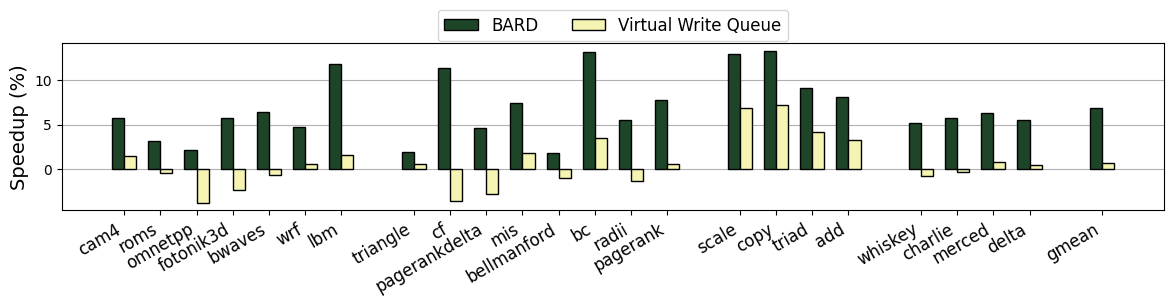

In [769]:
# Main evaluations:
plot_relative_stat('plots/main_evals.pdf',
                   ['baseline_close', 'bard_close_lookup16', 'vwq'],
                   'IPC',
                   'Speedup (%)',
                   ['BARD', 'Virtual Write Queue'],
                   [C3, C1, C4, C5])

IPC GMEAN of bard_e_close	6.371
IPC GMEAN of bard_c_close	5.507
IPC GMEAN of bard_close_lookup16	6.883
----------------------------


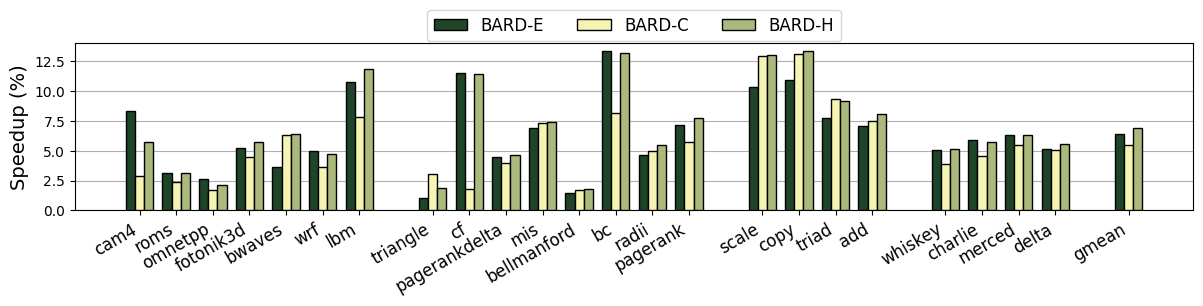

In [770]:
plot_relative_stat('plots/bard_ec_comparison.pdf',
                   ['baseline_close', 'bard_e_close', 'bard_c_close', 'bard_close_lookup16'],
                   'IPC',
                   'Speedup (%)',
                   ['BARD-E', 'BARD-C', 'BARD-H'],
                   [C3, C1, C4])

IPC GMEAN of bard_close_lookup4	5.484
IPC GMEAN of bard_close_lookup8	6.550
IPC GMEAN of bard_close_lookup16	6.642
IPC GMEAN of bard_close	6.217
----------------------------


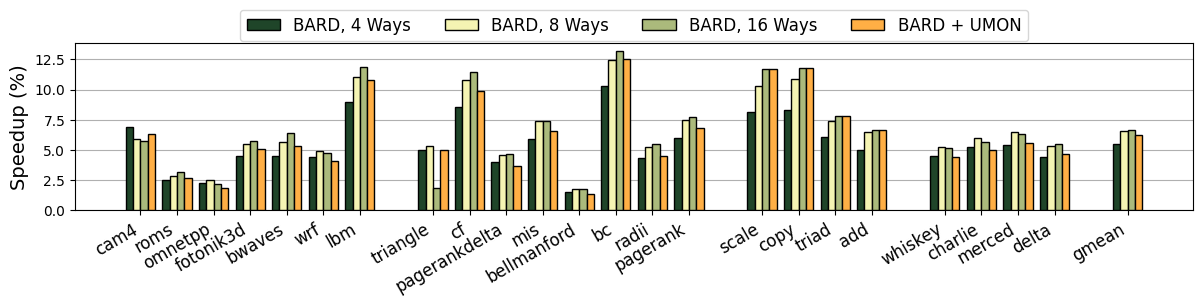

In [754]:
plot_relative_stat('plots/bard_lookup_comparison.pdf',
                   ['baseline_close', 'bard_close_lookup16_lookup4', 'bard_close_lookup16_lookup8', 'bard_close_lookup16_lookup16', 'bard_close_lookup16'],
                   'IPC',
                   'Speedup (%)',
                   ['BARD, 4 Ways', 'BARD, 8 Ways', 'BARD, 16 Ways', 'BARD + UMON'],
                   [C3, C1, C4, C5])
                   

In [755]:
### LRU SRAM OVERHEADS

LLC_CAPACITY = 16*1024*1024 * 8
LLC_ASSOC = 16
WCACHE_SAMPLED_SETS = 64
DRAM_CHANNELS = 2
DRAM_BANKS = 32

baseline_tagdir_size = (LLC_CAPACITY/(64*8)) * (48-14-6 + 2)

wcache_counters = LLC_ASSOC*8
wcache_mark_registers = LLC_ASSOC*5*WCACHE_SAMPLED_SETS
wcache_bitvec = DRAM_CHANNELS*DRAM_BANKS
wcache_tot = baseline_tagdir_size + wcache_counters + wcache_mark_registers + wcache_bitvec

baseline_bytes = baseline_tagdir_size / 8
wcache_bytes = wcache_tot/ 8

print(wcache_bytes / baseline_bytes)
print(wcache_bytes - baseline_bytes)

1.0006754557291666
664.0


In [756]:
## SRRIP SRAM OVERHEADS
RRIP_BITS=2

wcache_counters = (2**RRIP_BITS)*8
wcache_mark_registers = LLC_ASSOC*5*WCACHE_SAMPLED_SETS
wcache_bitvec = DRAM_CHANNELS*DRAM_BANKS
wcache_tot = baseline_tagdir_size + wcache_counters + wcache_mark_registers + wcache_bitvec

baseline_bytes = baseline_tagdir_size / 8
wcache_bytes = wcache_tot/ 8

print(wcache_bytes / baseline_bytes)
print(wcache_bytes - baseline_bytes)

1.0006632486979166
652.0


In [757]:
## tWRITE calculations
import math

def tWRITE_MISS(freq_ghz: float, CWL: int, BL: int, tWR: float, tRP: int, tRCD: int):
    return (CWL + BL/2 + math.ceil(tWR*freq_ghz) + tRP + tRCD) / freq_ghz

def tROUND_TRIP(freq_ghz: float, tCCD: int, n_banks: int):
    return n_banks * (tCCD/freq_ghz)

## DDR3:
ddr3_twrite_miss = tWRITE_MISS(0.8, 8, 8, 15.0, 11, 11)
ddr3_tround_trip = tROUND_TRIP(0.8, 4, 8)

## DDR5:
ddr5_twrite_miss = tWRITE_MISS(2.4, 38, 16, 30.0, 39, 39)
ddr5_tround_trip = tROUND_TRIP(2.4, 8, 32)

print(f'ddr3 tWRITE_miss = {ddr3_twrite_miss}, tROUND_TRIP = {ddr3_tround_trip}')
print(f'ddr5 tWRITE_miss = {ddr5_twrite_miss}, tROUND_TRIP = {ddr5_tround_trip}')

ddr3 tWRITE_miss = 57.5, tROUND_TRIP = 40.0
ddr5 tWRITE_miss = 81.66666666666667, tROUND_TRIP = 106.66666666666667


In [758]:
### Workload List
mpki_stats = get_stats_for_builds(['baseline_close'], 'MPKI', reference_mpki=reference_mpki, reference_wpki=reference_wpki)['baseline_close']
wpki_stats = get_stats_for_builds(['baseline_close'], 'WPKI', reference_mpki=reference_mpki, reference_wpki=reference_wpki)['baseline_close']
write_blp_stats = get_stats_for_builds(['baseline_close'], 'Write BLP', reference_mpki=reference_mpki, reference_wpki=reference_wpki)['baseline_close']
write_bglp_stats = get_stats_for_builds(['baseline_close'], 'Write BGLP', reference_mpki=reference_mpki, reference_wpki=reference_wpki)['baseline_close']

write_time_stats = get_stats_for_builds(['baseline_close'], 'Write Mode Fraction', reference_mpki=reference_mpki, reference_wpki=reference_wpki)['baseline_close']
ideal_write_time_stats = get_stats_for_builds(['baseline_close'], 'Ideal Write Mode Fraction', reference_mpki=reference_mpki, reference_wpki=reference_wpki)['baseline_close']

for w in mpki_stats:
    print(f'{w:16} &\t {mpki_stats[w] :.1f} &\t {wpki_stats[w] :.1f} &\t {write_blp_stats[w]: .1f} &\t {write_time_stats[w]*100: .1f} \\\\')

wrf              &	 19.3 &	 7.2 &	  16.0 &	  26.3 \\
roms             &	 8.0 &	 2.7 &	  7.7 &	  23.9 \\
cam4             &	 5.8 &	 3.8 &	  15.3 &	  35.6 \\
lbm              &	 33.8 &	 25.4 &	  24.3 &	  52.6 \\
omnetpp          &	 12.0 &	 5.4 &	  16.8 &	  22.2 \\
bwaves           &	 17.7 &	 6.1 &	  19.6 &	  32.1 \\
fotonik3d        &	 18.1 &	 9.7 &	  20.5 &	  32.2 \\
triangle         &	 8.9 &	 7.2 &	  17.3 &	  43.2 \\
pagerankdelta    &	 19.4 &	 7.9 &	  20.7 &	  26.4 \\
radii            &	 44.8 &	 15.9 &	  19.0 &	  28.6 \\
bc               &	 25.4 &	 19.6 &	  21.1 &	  50.5 \\
cf               &	 16.1 &	 16.0 &	  18.8 &	  44.7 \\
mis              &	 19.4 &	 10.6 &	  18.7 &	  39.3 \\
pagerank         &	 36.4 &	 10.9 &	  17.9 &	  27.5 \\
bellmanford      &	 29.4 &	 3.2 &	  19.7 &	  9.4 \\
scale            &	 41.7 &	 20.9 &	  21.3 &	  43.2 \\
add              &	 62.6 &	 20.8 &	  20.6 &	  33.2 \\
copy             &	 50.3 &	 25.1 &	  21.5 &	  44.1 \\
triad            &	 53.8 &	 18.0 &	  20.4 

In [759]:
### Mean write latency
write_latency = get_stats_for_builds(['baseline_close'], 'Write Latency', reference_mpki=reference_mpki, reference_wpki=reference_wpki)['baseline_close']

latency_list = [l for (_, l) in write_latency.items()]
mean_latency = sum(latency_list)/len(latency_list)

print(f'mean latency: {mean_latency/1000}')

mean latency: 5.67584623833834


Mean BLP: 19.2128941476176, Min: 7.7259235337176655, Max: 24.271223924687483


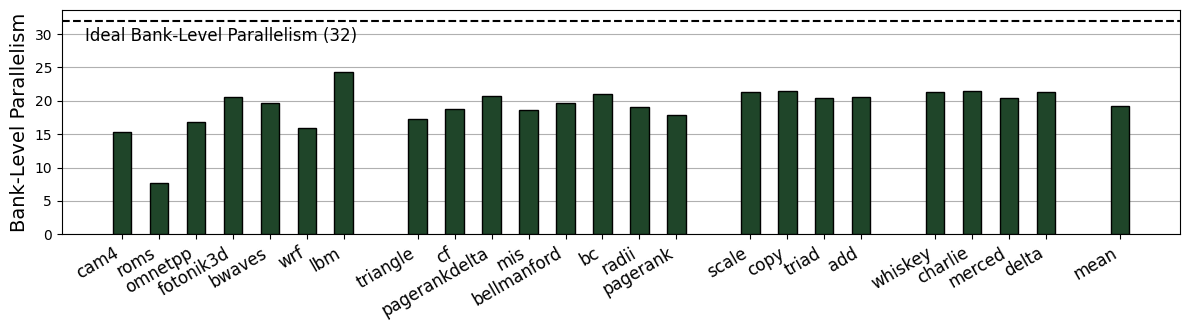

In [760]:
### Bank-Level parallelism
fig, ax = plt.subplots()
fig.set_size_inches(12.0, 3.4)

workload_labels = WORKLOAD_LIST.copy()
workload_labels.append('mean')

Yba = [write_blp_stats[w] for w in WORKLOAD_ORDER if w is not None]
Yba.append(sum(Yba)/len(Yba))
Yba = np.array(Yba)

#Ybg = [write_bglp_stats[w] for w in WORKLOAD_ORDER if w is not None]
#Ybg.append(sum(Ybg)/WORKLOAD_X.shape[0])
#Ybg = np.array(Ybg)

width = 1/2
ax.bar(WORKLOAD_X, Yba, width, color=C3, zorder=3, edgecolor='k', label='Bank-Level')
#ax.bar(WORKLOAD_X+width, Ybg, width, color=C1, zorder=3, edgecolor='k', label='Bankgroup-Level')

workload_order.append('mean')

ax.axhline(y=32, color='k', linestyle='--')
ax.text(-1.0, 29, 'Ideal Bank-Level Parallelism (32)', fontsize=12)

#ax.axhline(y=8, color='k', linestyle='--')
#ax.text(-1.0, 29, 'Ideal BGLP', fontsize=12)

ax.set_ylabel('Bank-Level Parallelism', fontsize=14)
ax.set_xticks(WORKLOAD_X, workload_labels, rotation=30, ha='right', fontsize=12)
ax.grid(visible=True, axis='y', zorder=0)

print(f'Mean BLP: {Yba[-1]}, Min: {min(Yba)}, Max: {max(Yba)}')

plt.tight_layout()
plt.savefig('plots/write_blp.pdf', bbox_inches='tight')

Time spent gmean: baseline = 31.815130519653934, ideal = 21.57674068526923


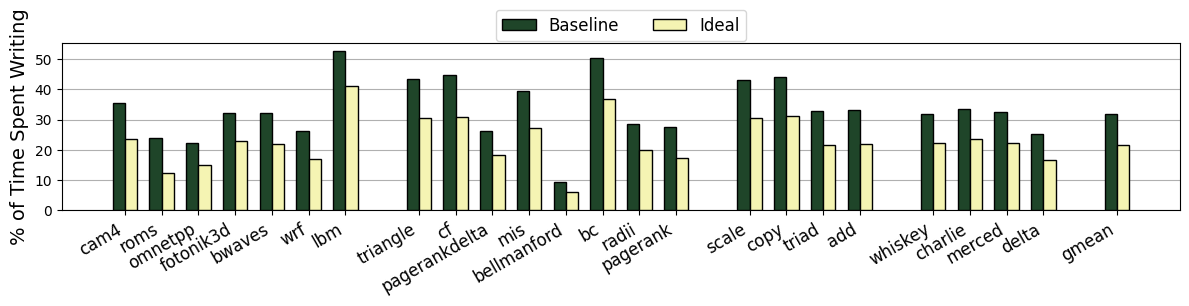

In [761]:
### Time in Write Mode
fig, ax = plt.subplots()
fig.set_size_inches(12.0, 3.4)

workload_labels = WORKLOAD_LIST.copy()
workload_labels.append('gmean')

Ybase = [write_time_stats[w] for w in WORKLOAD_ORDER if w is not None]
Yideal = [ideal_write_time_stats[w] for w in WORKLOAD_ORDER if w is not None]

Ybase.append(sp.stats.gmean(Ybase))
Yideal.append(sp.stats.gmean(Yideal))

Ybase = np.array(Ybase)*100
Yideal = np.array(Yideal)*100

width = 1.0/3.0

ax.bar(WORKLOAD_X, Ybase, width, color=C3, zorder=3, label='Baseline', edgecolor='k')
ax.bar(WORKLOAD_X+width, Yideal, width, color=C1, zorder=3, label='Ideal', edgecolor='k')

ax.set_ylabel('% of Time Spent Writing', fontsize=14)
ax.set_xticks(WORKLOAD_X + 1/2*width, workload_labels, rotation=30, ha='right', fontsize=12)
ax.grid(visible=True, axis='y', zorder=0)

ax.legend(fontsize=12, bbox_to_anchor=(0.5,1.25), ncol=2, loc='upper center')

plt.tight_layout()
plt.savefig('plots/write_mode_time.pdf', bbox_inches='tight')

#### Relevant stats:
print(f'Time spent gmean: baseline = {Ybase[-1]}, ideal = {Yideal[-1]}')


In [762]:
### Performance Headroom
ideal_speedup = get_stats_for_builds(['baseline_close'], 'Ideal Speedup', reference_mpki=reference_mpki, reference_wpki=reference_wpki)['baseline_close']

gmean = sp.stats.gmean([ideal_speedup[w] for w in WORKLOAD_ORDER if w is not None])
print(gmean)

1.1635710569628104


baseline_close	Mean BLP: 18.891334435861086, Min: 7.7259235337176655, Max: 24.271223924687483
bard_close_lookup16	Mean BLP: 26.161750752046636, Min: 9.179287530978268, Max: 31.05669228230105


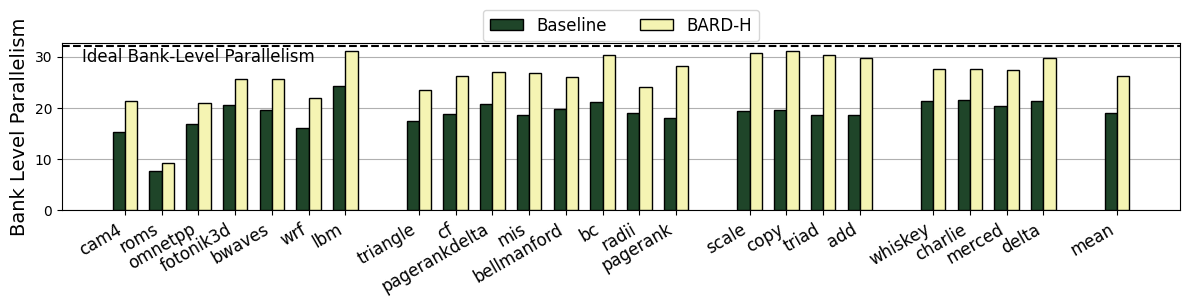

In [773]:
### Bank-Level parallelism comparison
fig, ax = plt.subplots()
fig.set_size_inches(12.0, 3.4)

workload_labels = WORKLOAD_LIST.copy()
workload_labels.append('mean')

BUILD_LIST = ['baseline_close', 'bard_close_lookup16']

write_blp_stats = get_stats_for_builds(BUILD_LIST, 'Write BLP', reference_mpki=reference_mpki, reference_wpki=reference_wpki)

label_list = ['Baseline', 'BARD-H']
color_list = [C3, C1, C4]

width = 1.0/(len(label_list)+1)
off = 0
for (i,b) in enumerate(BUILD_LIST):
    Y = [write_blp_stats[b][w] for w in WORKLOAD_ORDER if w is not None]
    Y.append(sum(Y)/len(Y))
    Y = np.array(Y)
    
    ax.bar(WORKLOAD_X+off, Y, width, color=color_list[i], zorder=3, label=label_list[i], edgecolor='k')
    off += width

    print(f'{b}\tMean BLP: {Y[-1]}, Min: {min(Y)}, Max: {max(Y)}')

ax.axhline(y=32, color='k', linestyle='--')
ax.text(-1.0, 29, 'Ideal Bank-Level Parallelism', fontsize=12)

ax.set_ylabel('Bank Level Parallelism', fontsize=14)
ax.set_xticks(WORKLOAD_X + 1/len(label_list)*width, workload_labels, rotation=30, ha='right', fontsize=12)
ax.grid(visible=True, axis='y', zorder=0)

ax.legend(fontsize=12, bbox_to_anchor=(0.5,1.25), ncol=len(label_list), loc='upper center')

plt.tight_layout()
plt.savefig('plots/write_blp_comparison.pdf', bbox_inches='tight')

baseline_close	Write Mode Time: 31.923307505861366, Min: 9.401053587663533, Max: 52.61041164758314
bard_close_lookup16	Write Mode Time: 26.472251774728424, Min: 7.859902600080513, Max: 46.97261580311665


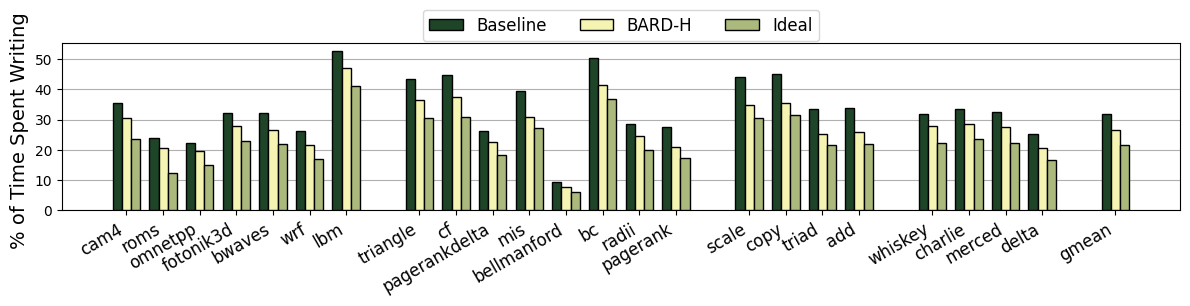

In [774]:
### Write Mode Times
fig, ax = plt.subplots()
fig.set_size_inches(12.0, 3.4)

workload_labels = WORKLOAD_LIST.copy()
workload_labels.append('gmean')

write_time_stats = get_stats_for_builds(BUILD_LIST, 'Write Mode Fraction', reference_mpki=reference_mpki, reference_wpki=reference_wpki)
ideal_time_stats = get_stats_for_builds(['baseline_close'], 'Ideal Write Mode Fraction', reference_mpki=reference_mpki, reference_wpki=reference_wpki)


width = 1.0/(len(label_list)+2)
off = 0
for (i,b) in enumerate(BUILD_LIST):
    Y = [100 * write_time_stats[b][w] for w in WORKLOAD_ORDER if w is not None]
    Y.append(sp.stats.gmean(Y))
    Y = np.array(Y)
    
    ax.bar(WORKLOAD_X+off, Y, width, color=color_list[i], zorder=3, label=label_list[i], edgecolor='k')
    off += width

    print(f'{b}\tWrite Mode Time: {Y[-1]}, Min: {min(Y)}, Max: {max(Y)}')
# Plot ideal
Yideal = [100 * ideal_time_stats['baseline_close'][w] for w in WORKLOAD_ORDER if w is not None]
Yideal.append(sp.stats.gmean(Yideal))
ax.bar(WORKLOAD_X+off, Yideal, width, color=C4, zorder=3, label='Ideal', edgecolor='k')

ax.set_ylabel('% of Time Spent Writing ', fontsize=14)
ax.set_xticks(WORKLOAD_X + width, workload_labels, rotation=30, ha='right', fontsize=12)
ax.grid(visible=True, axis='y', zorder=0)

ax.legend(fontsize=12, bbox_to_anchor=(0.5,1.25), ncol=len(label_list)+1, loc='upper center')

plt.tight_layout()
plt.savefig('plots/write_time_comparison.pdf', bbox_inches='tight')

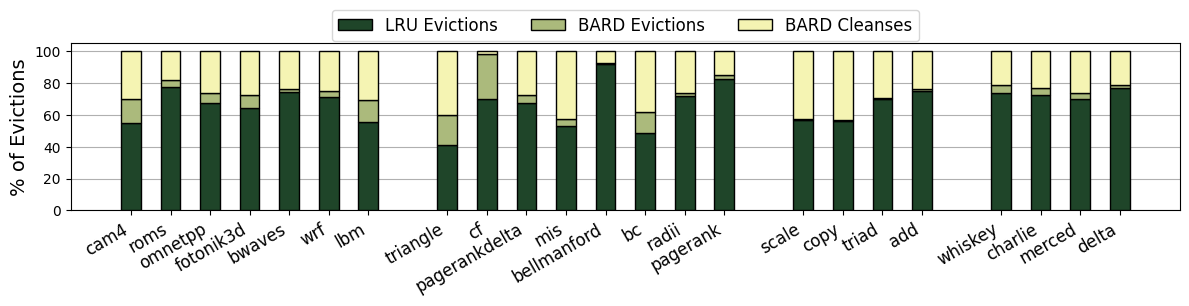

In [775]:
### Eviction Breakdown
fig, ax = plt.subplots()
fig.set_size_inches(12.0, 3.4)

workload_labels = WORKLOAD_LIST.copy()

total_evictions = get_stats_for_builds(['bard_close_lookup16'], 'Total Evictions', reference_mpki=reference_mpki, reference_wpki=reference_wpki)['bard_close_lookup16']
pw_evictions = get_stats_for_builds(['bard_close_lookup16'], 'PW Evictions', reference_mpki=reference_mpki, reference_wpki=reference_wpki)['bard_close_lookup16']
sw_evictions = get_stats_for_builds(['bard_close_lookup16'], 'SW Evictions', reference_mpki=reference_mpki, reference_wpki=reference_wpki)['bard_close_lookup16']

tot_e = [total_evictions[w] for w in WORKLOAD_ORDER if w is not None]
pw_e = [pw_evictions[w] for w in WORKLOAD_ORDER if w is not None]
sw_e = [sw_evictions[w] for w in WORKLOAD_ORDER if w is not None]

frac_norm = [(tot_e[i]-pw_e[i]-sw_e[i])/tot_e[i] for i in range(len(tot_e))]
frac_pw = [pw_e[i]/tot_e[i] for i in range(len(tot_e))]
frac_sw = [sw_e[i]/tot_e[i] for i in range(len(tot_e))]

frac_norm = np.array(frac_norm)*100
frac_pw = np.array(frac_pw)*100
frac_sw = np.array(frac_sw)*100

width = 0.5
ax.bar(WORKLOAD_X_NO_MEAN, frac_norm, width, label='LRU Evictions', color=C3, zorder=3, edgecolor='k')
ax.bar(WORKLOAD_X_NO_MEAN, frac_pw, width, label='BARD Evictions', bottom=frac_norm, color=C4, zorder=3, edgecolor='k')
ax.bar(WORKLOAD_X_NO_MEAN, frac_sw, width, label='BARD Cleanses', bottom=frac_norm+frac_pw, color=C1, zorder=3, edgecolor='k')

ax.set_ylabel('% of Evictions', fontsize=14)
ax.set_xticks(WORKLOAD_X_NO_MEAN, workload_labels, rotation=30, ha='right', fontsize=12)
ax.grid(visible=True, axis='y', zorder=0)
ax.set_ylim([0,105])

ax.legend(fontsize=12, bbox_to_anchor=(0.5,1.25), ncol=3, loc='upper center')

plt.tight_layout()
plt.savefig('plots/eviction_breakdown.pdf', bbox_inches='tight')